In [1]:
%matplotlib inline
import numpy as np
import xarray as xr
from datetime import datetime, timedelta
import cmocean
from matplotlib import pyplot as plt, rc,colors
import os
from salishsea_tools import visualisations as vis
import netCDF4 as nc
import pandas as pd
import matplotlib.dates as mdates
import seaborn as sns


In [2]:
M_path = '/home/jvalenti/MOAD/'
coords = xr.open_dataset(M_path+'grid/coordinates_seagrid_SalishSea201702.nc', decode_times=False)
mask = xr.open_dataset(M_path+'grid2/mesh_mask202108_TDV.nc')
lon = coords.nav_lon
x= np.linspace(0,lon.shape[1],lon.shape[1])
y = np.linspace(0,lon.shape[0],lon.shape[0])
X,Y = np.meshgrid(x,y)

In [3]:
jjii = xr.open_dataset('~/MOAD/grid/grid_from_lat_lon_mask999.nc')
def finder(lati,loni):
    j = [jjii.jj.sel(lats=lati, lons=loni, method='nearest').item()][0]
    i = [jjii.ii.sel(lats=lati, lons=loni, method='nearest').item()][0]
    return j,i

In [4]:
def make_filename(path_run,start,day, var='prod_T', res='d'):
    """Construct path prefix for local SHEM results given date object and paths dict
    """
    date  =  (start + timedelta(days=day))
    folder = date.strftime("%d%b%y").lower()
    prefix = os.path.join(path_run, f'{folder}/')
    fname = []
    for file in os.listdir(prefix):
        if (var in file) and ('_1'+res) in file:
            fname.append(file)
    if len(fname)>1:
        print('more than one file found') 
    
    return os.path.join(f'{folder}/', fname[0])

In [5]:
path_run = '/data/jvalenti/results/' 
day = 250
start = datetime(2025,1,1)
make_filename(path_run,start,day, var='biol_T', res='h')

Ox = xr.open_dataset(path_run+make_filename(path_run,start,day, var='biol_T', res='h')).dissolved_oxygen.isel(time_counter=0)
ox_0 = Ox*mask.tmask[0,0,:,:]
oxy_min = ox_0.where(ox_0 != 0).min(skipna=True,dim='deptht')

In [6]:
#(imin,imax,jmin,jmax)
regions = {'Jervis Inlet':(290,360,610,690),'Saanich Inlet':(173,220,325,360),'CSoG':(180,300,450,550),'Dabob Bay':(167,214,120,150), 'Lynch Cove': (120,150,67,76)}
colors_reg={'Jervis':'tab:blue','Sanich':'tab:orange','CSoG':'tab:green','Dabob Bay':'tab:red', 'Lynch Cove': 'tab:purple'}
def mark_region(axs,region,color = 'tab:blue'):
    coords = regions[region]
    x = [coords[0], coords[1], coords[1], coords[0], coords[0]]
    y = [coords[2], coords[2], coords[3], coords[3], coords[2]]
    axs.plot(x, y, color=color,label=region)


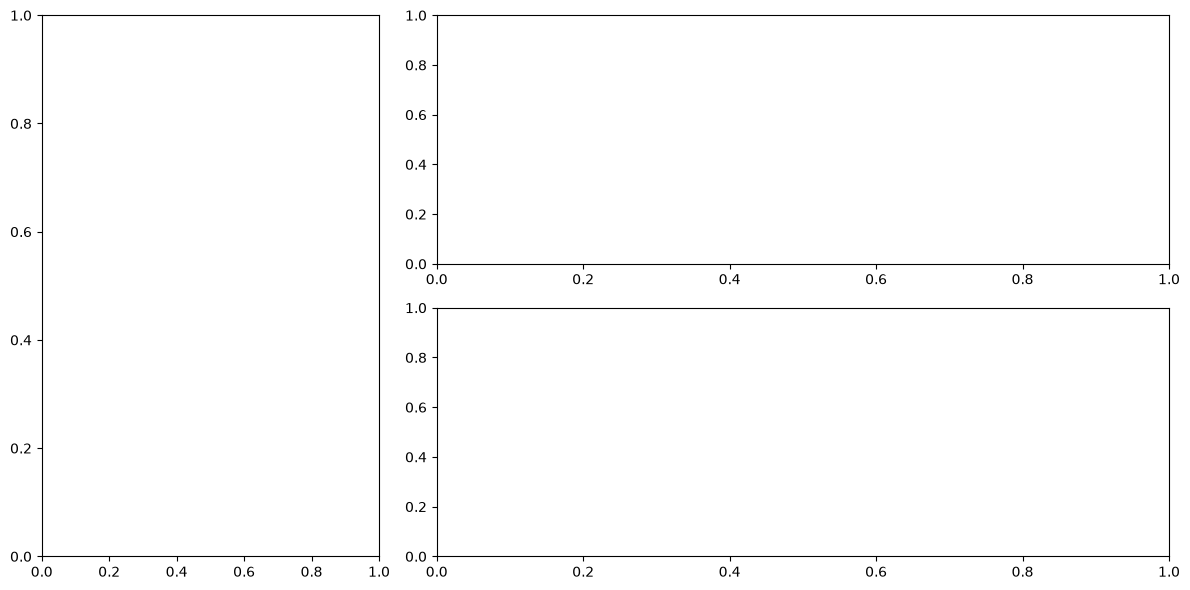

In [7]:
import matplotlib.gridspec as gridspec

colorsn=['tab:blue','tab:orange','tab:green','tab:red']

# Create a figure and a GridSpec layout
fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1], width_ratios=[1,1,1])

# Add the first two single large figures (one per column)
ax1 = fig.add_subplot(gs[:, 0])  # Occupies all rows in column 1

# Add the upper timeseries
ax3 = fig.add_subplot(gs[0, 1:])  # JdF & SoG
# Add the middle timeseries
ax5 = fig.add_subplot(gs[1, 1:])  # JdF & SoG


# Adjust layout for better visualization
plt.tight_layout()
plt.show()
axes = fig.get_axes()

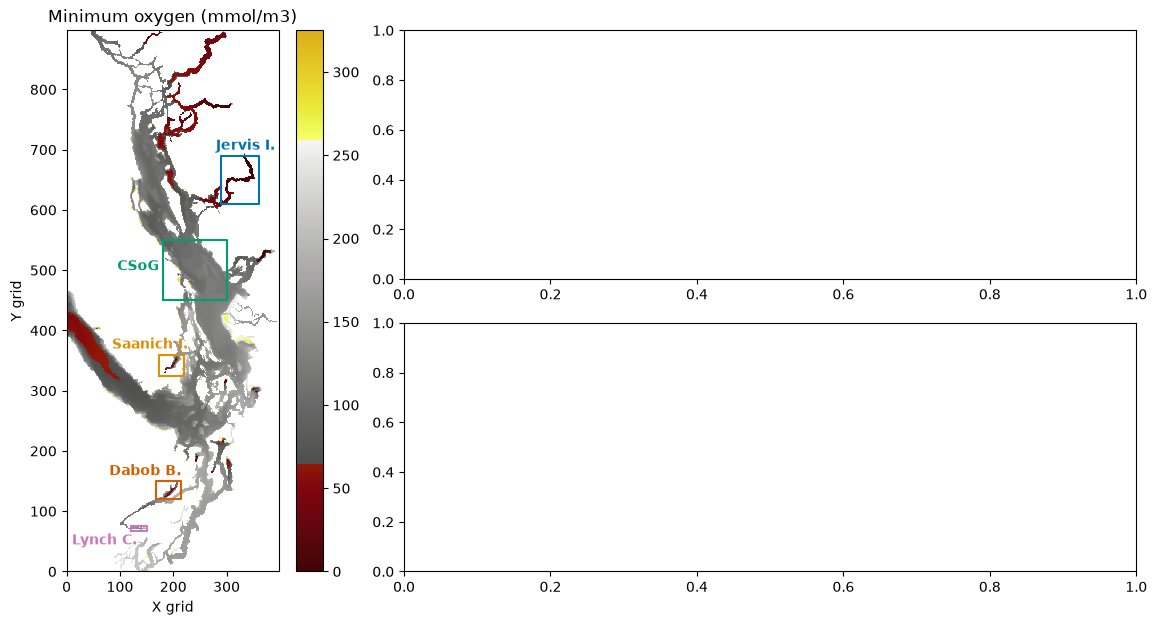

In [8]:
axes[0].clear()

cmap = cmocean.cm.oxy 

cb = sns.color_palette("colorblind")
aa = axes[0].pcolormesh(oxy_min,cmap=cmap,vmax =325,vmin=0)

f = 1.13
for i,region in enumerate(regions.keys()):
       mark_region(axes[0],region,color=cb[i])
axes[0].set_aspect(f)
axes[0].set_title('Minimum oxygen (mmol/m3)')
regions = {'Jervis Inlet':(290,360,610,690),'Saanich Inlet':(173,220,325,360),'CSoG':(180,300,450,550),'Dabob Bay':(167,214,120,150), 'Lynch Cove': (120,150,67,76)}

axes[0].text(280,700,f'Jervis I.',c = cb[0], fontweight="bold")
axes[0].text(85,370,f'Saanich I.',c = cb[1], fontweight="bold")
axes[0].text(95,500,f'CSoG',c = cb[2], fontweight="bold")
axes[0].text(80,160,f'Dabob B.',c = cb[3], fontweight="bold")
axes[0].text(10,45,f'Lynch C.',c = cb[4], fontweight="bold")

axes[0].set_ylabel('Y grid')
axes[0].set_xlabel('X grid')

cbar = fig.colorbar(aa, ax=axes[0])

fig

In [10]:
count_hypox_reg = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/count_shem_hypox_reg_2325.npy')
count_hypox = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/count_shem_hypox_full_2325.npy')

count_hypox_reg_2021 = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/count_hypox_reg_2325.npy')
count_hypox_2021 = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/count_hypox_full_2325.npy')

count_hypox_reg_oxy = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/count_oxyv2_hypox_reg.npy')
count_hypox_oxy = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/count_oxyv2_hypox_full.npy')


In [12]:
axes[1].clear() 

time = pd.date_range(start='2023-01-01',end='2025-12-31',freq='D')

for i, region in enumerate(regions.keys()):
    axes[1].plot(time, count_hypox_reg[i,:]-count_hypox_reg_2021[i,:], label=region, color=cb[i], linestyle='-')
    #plt.plot(time, count_hypox_reg_2021[i,:],  color=cb[i], linestyle=':',marker='v', markevery=10, markersize=4)
    axes[1].plot(time, count_hypox_reg_oxy[i,:]-count_hypox_reg_2021[i,:],  color=cb[i], linestyle='--',marker='v', markevery=10, markersize=4)
    

#count = count_hypox[~np.isnan(count_hypox[:])]
#count2 = count_hypox_2021[~np.isnan(count_hypox_2021[:])]
#count3 = count_hypox_oxy[~np.isnan(count_hypox_oxy[:])]

#plt.plot(time2, count, label='Full domain', color='black', linestyle='-')
#plt.plot(time2, count2,  color='black', linestyle='--')
#plt.plot(time2[:1094], count3, color='black', linestyle=':')

axes[1].set_ylabel('Percent change in hypoxic area')
axes[1].set_title('Change in hypoxic area relative to v202111')

axes[1].set_xticks([])
#axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
#axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b%y'))
#axes[1].tick_params(axis='x', labelrotation=45)
axes[1].set_xlim(pd.Timestamp("2024-01-01"), pd.Timestamp("2025-12-31"))
axes[1].yaxis.tick_right()
axes[1].yaxis.set_label_position('right')
#plt.legend(loc=1)


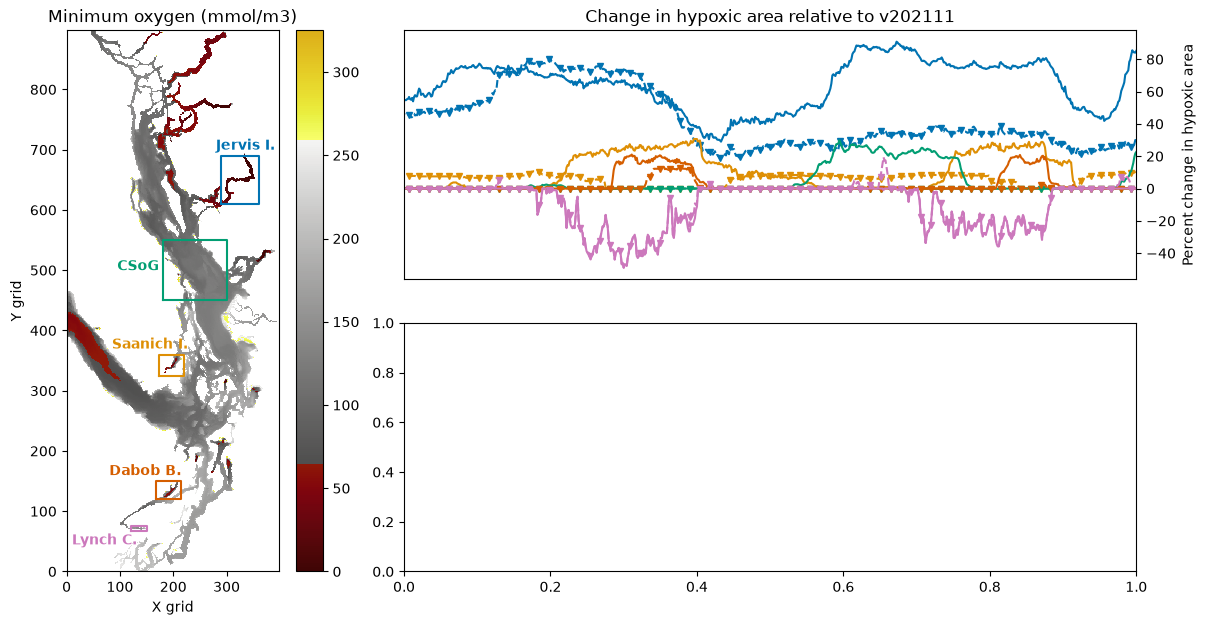

In [13]:
fig

In [14]:
mean_oxy_2021 = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/meano2_full_2325.npy')
mean_oxy_reg_2021 = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/meano2_regions_2325.npy')

mean_oxy = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/oxy_meano2_full_2325.npy')
mean_oxy_reg = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/shem_meano2_regions_2325.npy')

mean_oxy_oxy = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/oxyv2_meano2_full.npy')
mean_oxy_reg_oxy = np.load('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/oxyv2_meano2_regions.npy')


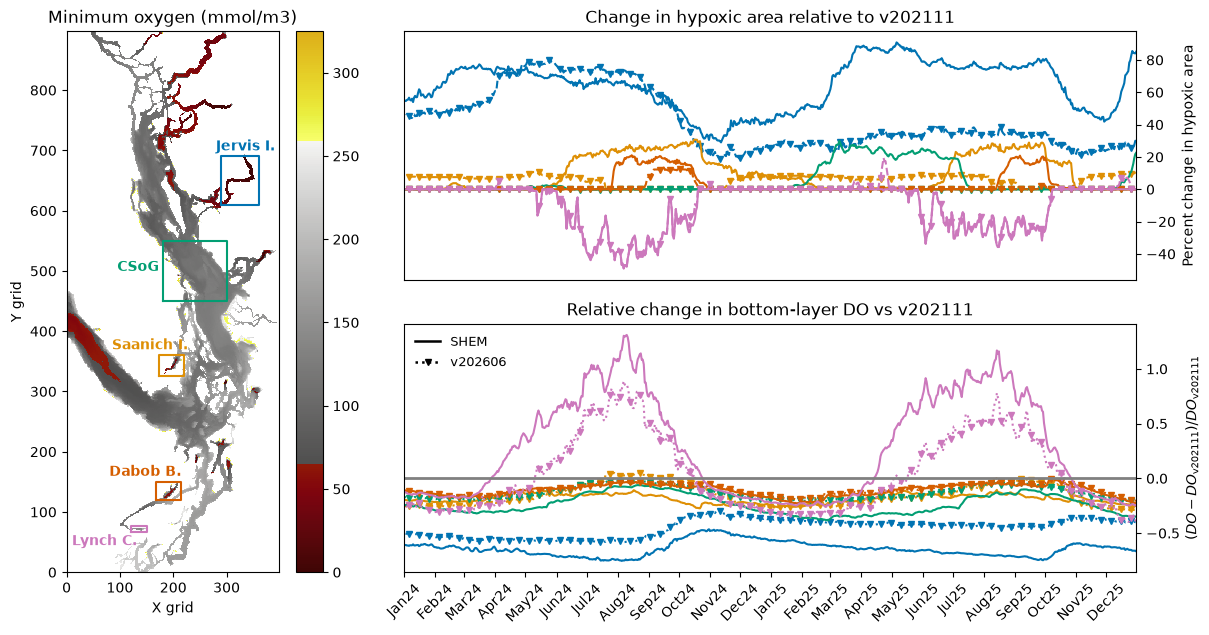

In [16]:
axes[2].clear() 

for i, region in enumerate(regions.keys()):

    reg_count = mean_oxy_reg[i,~np.isnan(mean_oxy_reg[i,:])]
    reg_count3 = mean_oxy_reg_oxy[i,~np.isnan(mean_oxy_reg_oxy[i,:])]
    reg_count2 = mean_oxy_reg_2021[i,~np.isnan(mean_oxy_reg_2021[i,:])]
    
    axes[2].plot(time, (reg_count-reg_count2)/reg_count2, label=region, color=cb[i],linestyle='-')
    axes[2].plot(time, (reg_count3-reg_count2)/reg_count2, color=cb[i],linestyle=':',marker='v', markevery=10, markersize=4)


axes[2].axhline(0, color='grey', linewidth=2)
axes[2].set_ylabel( r'$(DO - DO_{\mathrm{v202111}})/DO_{\mathrm{v202111}}$')
axes[2].set_title('Relative change in bottom-layer DO vs v202111')

axes[2].xaxis.set_major_locator(mdates.MonthLocator())
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b%y'))
axes[2].set_xlim(pd.Timestamp("2024-01-01"), pd.Timestamp("2025-12-31"))

axes[2].tick_params(axis='x', labelrotation=45)

axes[2].yaxis.tick_right()
axes[2].yaxis.set_label_position('right')

from matplotlib.lines import Line2D

style_legend = [
    Line2D([0], [0],color='black',linestyle='-',linewidth=1.8,label='SHEM'),
    Line2D([0], [0],color='black',linestyle=':',linewidth=1.8,marker='v',markersize=4,label='v202606')
]

axes[2].legend(handles=style_legend,loc='upper left',frameon=False,fontsize=9)
#plt.legend(loc=1)
fig

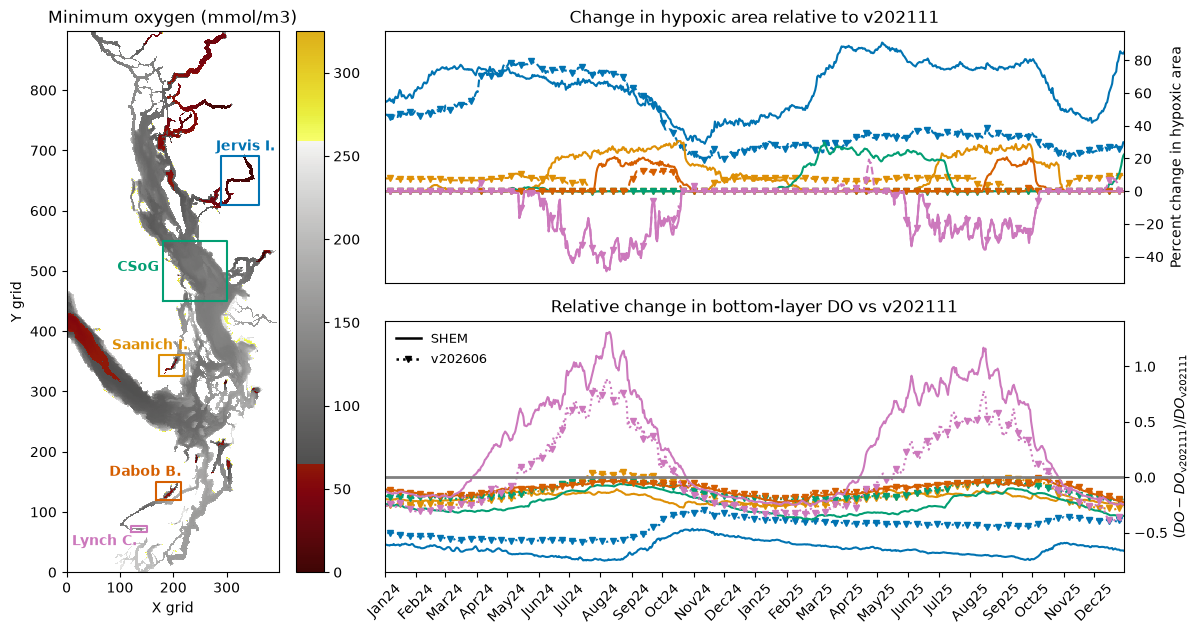

In [17]:
fig.subplots_adjust(hspace=0.15,wspace=0.1)
fig

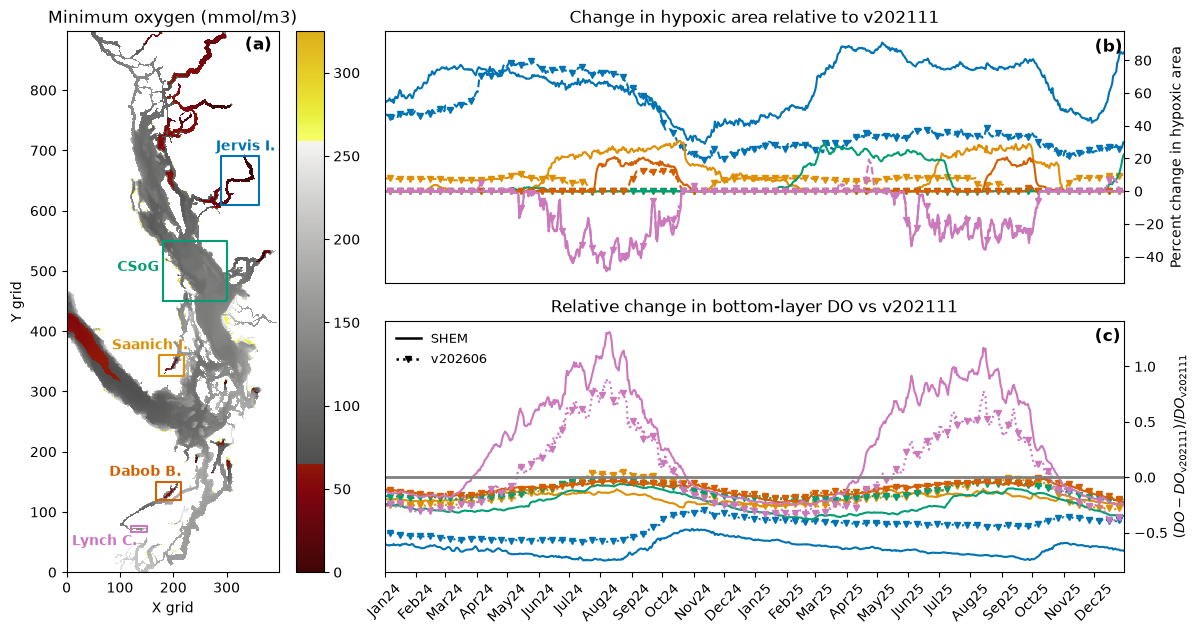

In [18]:
letters = ['(a)', '(b)', '(c)']

axes[0].text(0.84, 0.99, letters[0], transform=axes[0].transAxes, fontsize=12, fontweight='bold', va='top')
axes[1].text(0.96, 0.97, letters[1], transform=axes[1].transAxes, fontsize=12, fontweight='bold', va='top')
axes[2].text(0.96, 0.97, letters[2], transform=axes[2].transAxes, fontsize=12, fontweight='bold', va='top')
fig

In [19]:
fig.savefig('hypoxia_v2.pdf',bbox_inches='tight')